In [43]:
using GLPK, JuMP, Plots
using Measures
# import Pkg
# Pkg.add("Measures")
# using Random
# Random.seed!(42)

# HEAT-PUMP 
costs depend on **electricity costs** (constant) & **outside-temperature**
additionaly the efficiency depends on the **outside-temperature**

$$
    COP = \frac{Q}{W}
$$
Q...generated Heat

W...used electrical energy

if | outside_temperature - fluent_temperature | is big, then $COP$ is small

formula in *Kelvin*:
$$
COP = \frac{T_{heat}}{T_{heat} - T_{out}}
$$
$$
    COP(T_{out}) \text{ is approx. } \frac{1}{T_{heat}-T_{heat}}
$$

Heatpump needs W...elecricity $\rightarrow$ cost
$$
W = \frac{Q}{COP}
$$

In [44]:
#DATA
N = 24      # amount timesteps   
M = 3       # amount heatsources

# 1 biomass boiler
# 2 gas boiler
# 3 heat pump

c = [185, 600, 260]            # Cost           - DKK / MWh
m = [150, 150, 150]         # Capacity          - MW
ramp_up = [30,100,60]       # Heat-up-speed     - MW / time step
ramp_down = [10,100,60];    # Cool-down-speed   - MW / time step

# DEMAND
# d = rand(0:450, N)
d = [370, 200, 230, 270, 450, 280, 240, 210, 370, 190, 180, 200, 0, 270, 300, 280, 240, 210, 260, 190,0,450,0,100];   # MW 
T = [-5, -4, -3, 0, 1, 3, 4, 6, 7, 10, 13, 15, 17, 16, 15, 13, 11, 9, 7, 7, 5, 2, -2, -3]

# HEATPUMP-PRICE due to less effiency
electricity_price = 800   # DKK/MWh 
COP = clamp.(2.5 .+ 0.08 .* T, 1.5, 5.0)

heatpump_cost = electricity_price ./ COP;

# HEATPUMP-CAPACITY
HP_capacity = clamp.(150 .* (0.7 .+ 0.015 .* T), 80, 150);


In [45]:
model1 = Model(GLPK.Optimizer)

@variable(model1, x1[1:M,1:N] >= 0)

# minimize COST
@objective( model1, Min, sum(  x1[1,t] * c[1]   +   x1[2,t] * c[2]   +   x1[3,t] * heatpump_cost[t] for t=1:N) )

# CONSTRAINTS
# capacity
@constraint(model1, [j=1:2,i=1:N], x1[j,i] <= m[j])
@constraint(model1, [t=1:N], x1[3,t] <= HP_capacity[t])
# meet Demand
@constraint(model1, [i=1:N],   sum( x1[j,i] for j=1:M) >= d[i]    )
# ramp_up/down
@constraint(model1, [j=1:M, i=2:N],  x1[j,i] - x1[j,i-1] <= ramp_up[j])
@constraint(model1, [j=1:M, i=2:N],  x1[j,i-1] - x1[j,i] <= ramp_down[j])

optimize!(model1)

println("Solver status: ", termination_status(model1))
println("Solution status: ", primal_status(model1))
## Printing the solution
println("Objective value = ", objective_value(model1)) 

cost1 = 0
for j=1:M
    for i=1:N
        print(round(value(x1[j,i]),digits=2),"\t")
        cost1 += value(x1[j,i])*c[j]
    end
    println()
end
cost_Euro = round(cost1/7.5,digits=2)
println("Cost: ",cost1/1000000, " Million DKK \t (",cost_Euro, " in €)")

Solver status: INFEASIBLE
Solution status: NO_SOLUTION
Objective value = 1.6981575791894165e6
150.0	120.0	150.0	150.0	150.0	150.0	150.0	149.25	150.0	129.25	71.25	61.25	51.25	150.0	150.0	150.0	150.0	150.0	150.0	140.0	130.0	150.0	140.0	130.0	
80.0	0.0	0.0	92.75	192.75	92.75	0.0	0.0	99.25	0.0	0.0	0.0	0.0	-21.0	11.25	0.0	0.0	0.0	-10.75	0.0	90.5	190.5	90.5	0.0	
140.0	80.0	80.0	27.25	107.25	37.25	90.0	60.75	120.75	60.75	108.75	138.75	81.0	141.0	138.75	130.0	90.0	60.0	120.75	50.0	49.5	109.5	49.5	0.0	
Cost: 1.67980625 Million DKK 	 (223974.17 in €)


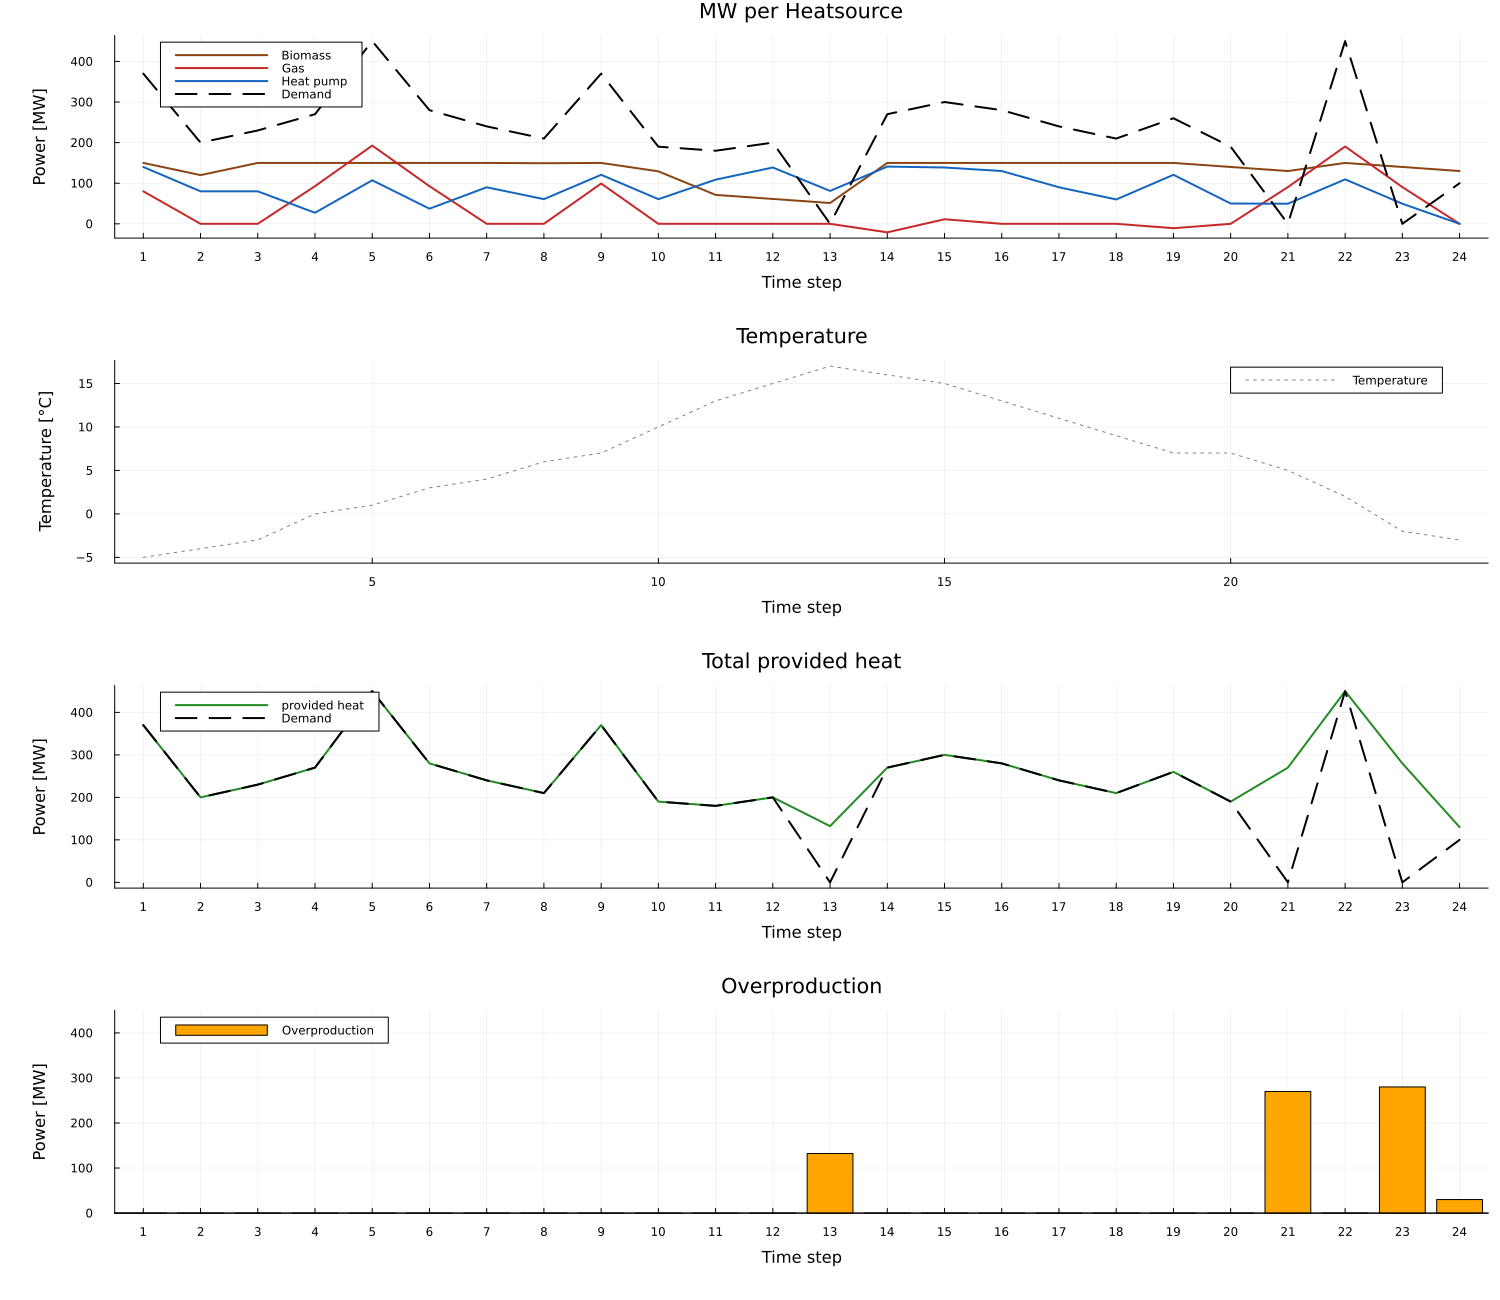

In [46]:
xmin = 0.5
xmax = N + 0.5
# Biomass - forest green
# Gas - dark red
# Heat pump - blue

# 1. HEAT SOURCES
p = plot( 1:N, 
        [value.(x1[j,:]) for j in 1:3], 
        labels=["Biomass" "Gas" "Heat pump"], 
        color = ["#8B4513" "#C62828" "#1565C0"],
        xlabel="Time step", 
        ylabel="Power [MW]", 
        lw=2 , 
        title="MW per Heatsource",
        xticks=1:N,
        grid=true,
        xlims = (xmin,xmax))
plot!(p, 1:N, 
        d, 
        label="Demand", 
        lw=2, 
        linestyle=:dash,
        color=:black )

# TEMPERATURE PLOT
p_temp = plot(1:N,
        T,
        label="Temperature",
        lw=1,
        color=:grey,
        xlabel="Time step",
        ylabel="Temperature [°C]",
        title="Temperature",
        linestyle=:dot,
        xlims = (xmin,xmax))

# 2. TOTAL PROVIDED HEAT
x1_result = value.(x1)

total = zeros(N)
for i=1:M
    total = total .+ x1_result[i,:]
end

p_total = plot(1:N, total, label="provided heat", lw=2,
        title="Total provided heat",
        color="#228B22",
        xticks=1:N,
        grid=true,
        xlims = (xmin,xmax),
        legend=:topleft)
plot!(p_total, 1:N, d,   label="Demand", lw=2, linestyle=:dash,color=:black)

xlabel!(p_total, "Time step")
ylabel!(p_total, "Power [MW]")

# 3. OVERPRODUCTION
ymax = maximum(d)
overproduction = max.(total .- d, 0)

p_overproduction = bar(1:N,
    overproduction,
    label="Overproduction",
    color=:orange,
    xlabel="Time step",
    ylabel="Power [MW]",
    title="Overproduction",
    xticks=1:N,
    ylims=(0,ymax),
    grid=true,
    xlims = (xmin,xmax),
    legend=:topleft)

hline!(
    p_overproduction,
    [0],
    color=:black,
    lw=1,
    label="")

p_combined = plot( p,p_temp,p_total,p_overproduction,
    layout=@layout([
        a 
        b
        c
        e
    ]),    
    link=:x,
    left_margin=12mm,
    bottom_margin=8mm,
    size=(1500,1300))

display(p_combined)


## Thermal storage

**For Model 2:**

- Maximum storage capacity: **150 MWh**
- Initial storage level: **75 MWh** (Final storage level must equal the initial storage level)
- Maximum charging power: **75 MW**
- Maximum discharging power: **75 MW**
- Charging efficiency: **95 %**
- Discharging efficiency: **95 %**
- No standing losses are considered. 
- Charging and discharging are continuously.
- **Excess heat** may be discarded if it cannot be used or stored.

In [47]:
# 2opt
#THERMAL STORAGE
E_maxCharge = 75        # MW
E_maxDischarge = 75     # MW   
E_max = 150             # Storage Capacity  - MWh
E_start = 75           # Start Capacity    - MWh   

eff_charge = 0.95        # Heat loss while charging        
eff_discharge = 0.95     # Heat loss while discharging
eff_storage = 1.        # Heat loss while storing       - no influence!


using GLPK, JuMP, Plots
model2 = Model(GLPK.Optimizer)

@variable(model2, x2[1:3,1:N] >= 0)

@variable(model2, E[1:N] >= 0)
@variable(model2, charge[1:N] >= 0)
@variable(model2, discharge[1:N] >= 0)
@variable(model2, excessHeat[1:N] >= 0)

# KOSTEN minimieren
@objective( model2, Min, sum(  x2[1,t] * c[1]   +   x2[2,t] * c[2]   +   x2[3,t] * heatpump_cost[t] for t=1:N) )
# CONSTRAINTS:
# kann maximalen Wirkungsgrad nicht übersteigen    -    je Heizquelle
@constraint(model2, [j=1:2,t=1:N], x2[j,t] <= m[j])
@constraint(model2, [t=1:N], x2[3,t] <= HP_capacity[t])

# DEMAND hast to be met     -    für alle Zeitpunkte i
# @constraint(model, [t=1:N],   sum( x2[j,t] for j=1:M) >= d[t]    )

# heating speed
@constraint(model2, [j=1:M, t=2:N],  x2[j,t] - x2[j,t-1] <= ramp_up[j])
@constraint(model2, [j=1:M, t=2:N],  x2[j,t-1] - x2[j,t] <= ramp_down[j])

# SPEICHER
@constraint(model2, [t=1:N], charge[t]    <= E_maxCharge)                                 # charging-speed
@constraint(model2, [t=1:N], discharge[t] <= E_maxDischarge)
@constraint(model2, [t=1:N], E[t]         <= E_max)                                       # storage-capazity
@constraint(model2, [t=1:N], sum( x2[i,t] for i=1:M) + discharge[t] == d[t] + charge[t] + excessHeat[t])      # heat-equality

@constraint(model2, [t=2:N], E[t] == eff_storage * E[t-1] + eff_charge * charge[t] - 1/eff_discharge * discharge[t])          # keep track of storage
@constraint(model2, E[1] == E_start + eff_charge * charge[1] - 1/eff_discharge * discharge[1])
@constraint(model2, E[N] == E_start)

optimize!(model2)

println("Solver status: ", termination_status(model2))
println("Solution status: ", primal_status(model2))
## Printing the solution
println("Objective value = ", objective_value(model2)) 

cost2 = 0
for j=1:M
    for i=1:N
        print(round(value(x2[j,i]),digits=2),"\t")
        cost2 += value(x2[j,i])*c[j]
    end
    println()
end
cost2_Euro = round(cost2/7.5,digits=2)
println("\nCost: ",round(cost2/1000000,digits=4), " Million DKK \t (",cost2_Euro, " in €)\n")

println("Excess Heat:\n",round.(value.(excessHeat),digits=2))

Solver status: OPTIMAL
Solution status: FEASIBLE_POINT
Objective value = 1.4321555208125205e6
150.0	150.0	150.0	150.0	150.0	150.0	150.0	150.0	150.0	150.0	140.0	130.0	120.0	150.0	150.0	150.0	150.0	150.0	140.0	130.0	120.0	150.0	140.0	130.0	
69.53	0.0	0.0	17.75	117.75	18.25	0.0	0.0	24.79	0.0	0.0	0.0	0.0	0.0	0.0	0.0	0.0	0.0	0.0	0.0	15.5	115.5	15.5	0.0	
93.75	96.0	98.25	105.0	107.25	111.75	114.0	118.5	120.75	60.75	113.23	60.0	0.0	60.0	120.0	134.25	90.0	60.0	95.49	35.49	49.5	109.5	49.5	0.0	

Cost: 1.3958 Million DKK 	 (186101.77 in €)

Excess Heat:
[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 45.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 110.0, 0.0, 156.05, 0.0]


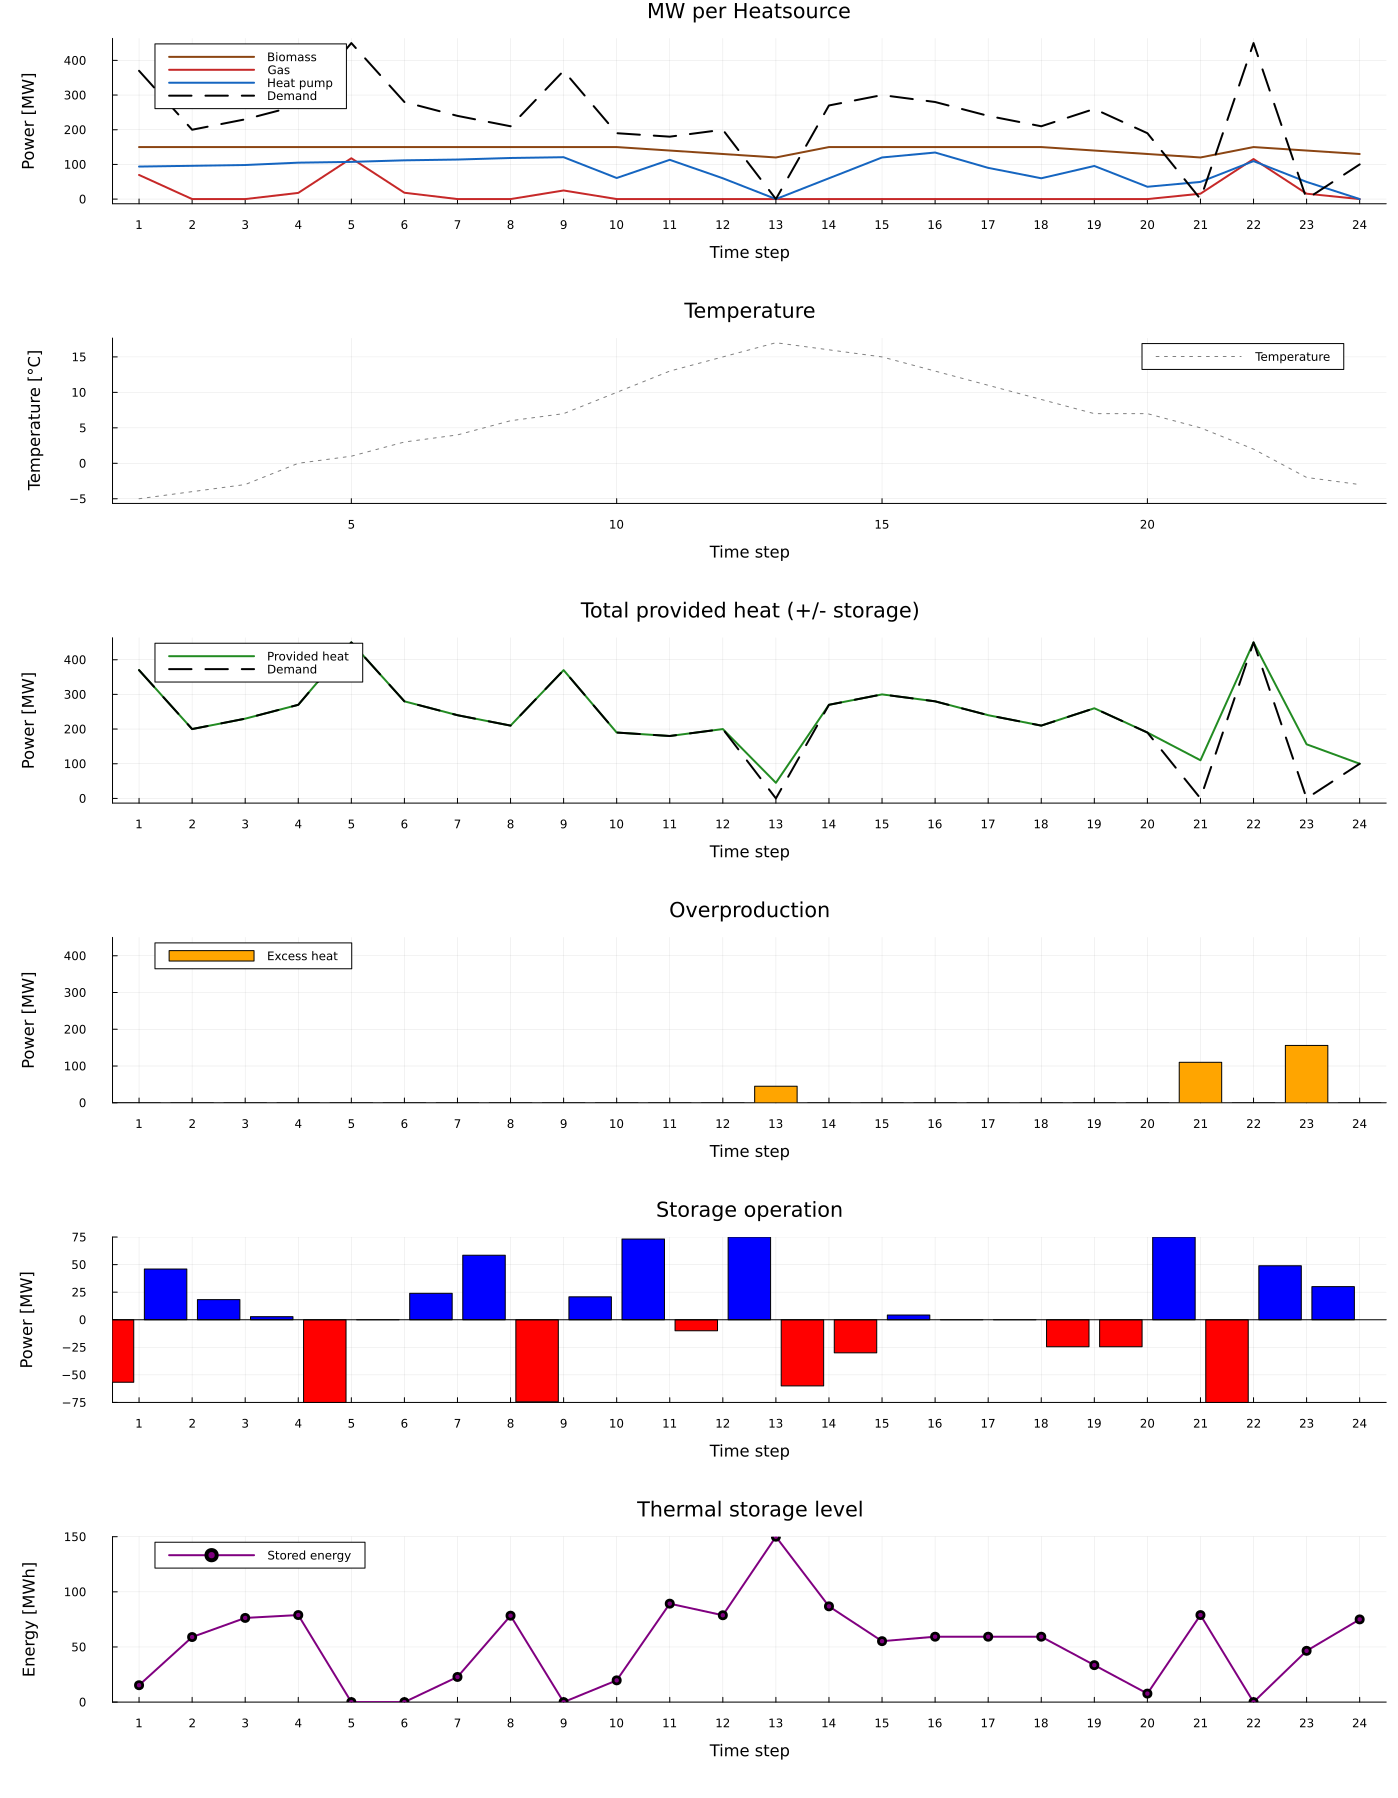

In [ ]:
xmin = 0.5
xmax = N + 0.5
# PLOT RESULTS - MODEL WITH STORAGE
x2_result = value.(x2)

biomass = x2_result[1,:]
gas = x2_result[2,:]
heatpump = x2_result[3,:]

charge_result = value.(charge)
discharge_result = value.(discharge)
storage_level = value.(E)
storage_movement = discharge_result .- charge_result
# positive = storage gives heat
# negative = storage gets heat

# total heat provided to demand
total_generation = biomass .+ gas .+ heatpump
provided_heat = total_generation .+ storage_movement

# heat produced above actual demand
# excess_heat = max.(provided_heat .- d, 0)
excess_heat = value.(excessHeat)

# 1. HEAT SOURCES
p_sources = plot(1:N, 
    biomass,    label="Biomass",
    color="#8B4513",lw=2,
    xlabel="Time step",
    ylabel="Power [MW]",
    title="MW per Heatsource",
    xticks=1:N,
    grid=true,
    xlim = (xmin,xmax))
plot!(p_sources,1:N,gas, label="Gas",color="#C62828",lw=2)
plot!(p_sources,1:N, heatpump, label="Heat pump", color="#1565C0",lw=2)
plot!(p_sources,1:N,d, label="Demand",color=:black,lw=2,linestyle=:dash)

# TEMPERATURE-PLOT
p_temp = plot(1:N,
        T,
        label="Temperature",
        lw=1,
        color=:grey,
        xlabel="Time step",
        ylabel="Temperature [°C]",
        title="Temperature",
        linestyle=:dot,
        xlims = (xmin,xmax))

# 2. TOTAL PROVIDED HEAT (with storage)
p_total = plot(1:N,
    provided_heat,  label="Provided heat",
    color="#228B22",lw=2,
    xlabel="Time step",
    ylabel="Power [MW]",
    title="Total provided heat (+/- storage)",
    xticks=1:N,
    grid=true,
    xlim = (xmin,xmax),
    legend=:topleft)
plot!(p_total,1:N,
    d, label="Demand",
    color=:black,lw=2,linestyle=:dash)
    
# 3. EXCESS HEAT
p_excess = bar(1:N,
    excess_heat,
    label="Excess heat",color=:orange,
    xlabel="Time step",
    ylabel="Power [MW]",
    title="Overproduction",
    xticks=1:N,
    grid=true,
    ylims=(0,ymax),
    xlim = (xmin,xmax),
    legend=:topleft
    )

# 4. STORAGE MOVEMENT
movement_time = (1:N) .- 0.5
bar_colors = [-storage_movement[i] >= 0 ? :blue : :red     for i in 1:length(storage_movement)]
# storage_movement[1] = 0

p_movement = bar(
    movement_time,
    -storage_movement,
    label="",
    color=bar_colors,
    xlabel="Time step",
    ylabel="Power [MW]",
    title="Storage operation",
    xticks=1:N,
    grid=true,
    xlim = (xmin,xmax))

hline!(p_movement,[0],color=:black,lw=1,label="")

# 5. STORAGE LEVEL
p_storage = plot(1:N,
    storage_level,
    label="Stored energy",
    color=:purple,lw=2,
    marker=:circle,
    xlabel="Time step",
    ylabel="Energy [MWh]",
    title="Thermal storage level",
    xticks=1:N,
    grid=true,
    ylims=(0,E_max),
    xlim = (xmin,xmax),
    legend=:topleft)

# COMBINED PLOT
p_combined = plot(
    p_sources, p_temp, p_total, p_excess, p_movement, p_storage,
    layout=@layout([
        a
        b
        c
        d
        e
        f
        ]),
    link=:x,
    left_margin=12mm,
    bottom_margin=8mm,
    size=(1400,1800))

display(p_combined)

## Conclusion

*General:*

- Biomass covers most of the base load
- Heat pump supports medium demand
- Gas mainly covers peak demand

*Storage:*

- **Storage** reduces expensive peak production
- Ramp constraints can cause overproduction


- 150 MWh storage capacity appears oversized

**Possible options to improve the system:**
- increase Charging/discharging power
- reduce storage capacity
- Minimum reserve level *(50 MWh)* could improve reliability
